Duilio Lucio, Vivian Hu

Spring 2026

CS 343: Neural Networks

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from adaline import Adaline

# Set the color style so that Professor Layton can see your plots
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
# Make the font size larger
plt.show()
plt.rcParams.update({'font.size': 18})

# Turn off scientific notation when printing
np.set_printoptions(suppress=True, precision=3)

# Automatically reload your external source code
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Project 1 | Single-Layer Networks

In this project, you will implement single-layer neural networks that includes the same fundamental components as larger multi-layer networks. You will get familiar with the most common "neural network workflow":
- preprocessing data
- training a neural network
- evaluating test data
- examining performance metrics

We will take advantage of the relative simplicity of single-layer neural networks to analyze and visualize the learned class decision boundaries (*this is more difficult and less intuitive in more complex neural networks that we will study!*).

You will also investigate how the same neural network architecture can be used for both classification and regression with only modest changes.

#### Reminders

- In this class, use `numpy ndarray` (`np.array()`), not Numpy Matrix.
- To help safeguard against data loss when working in a jupyter notebook, make sure the notebook is `Trusted` (Top right corner of notebook when opened in your browser). This will ensure your work autosaves. **I still recommend manually saving at least every few minutes with (Control+S / Cmd+S)**

## Task 1: Implement the ADAptive LInear NEuron (ADALINE) network for binary classification

In Task 1, complete the methods of the `Adaline` class in `adaline.py`. This includes:

- `net_input(self, features)`
- `activation(self, net_in)`
- `loss(self, errors)`
- `accuracy(self, y, y_pred)`
- `gradient(self, errors, features)`

- `predict(self, features)`
- `fit(self, features, y, n_epochs, lr)`

**Important:** Before starting, read through the method descriptions and expected inputs/outputs. It probably would be a good idea to tackle simpler/smaller methods first, then use them in more complex ones. For example, it may be a good idea to work on `net_input` first because it is required to complete `fit`. There is test code below.

Here is a summary of the ADALINE network equations

##### Net input

$\vec{x}_i$ is one of the $N$ data sample vectors from the dataset matrix $A$. That is, `x_i.shape = (M,)`.

$$\text{netIn}_i = \sum_{j=1}^M x_{ij} w_j + b$$

##### Net activation

Identity function:

$$ f(x) = x $$

So:

$$\text{netAct}_i = \text{netIn}_i$$


##### Loss: Sum of squared error

$$L(\vec{w}) = \frac{1}{2} \sum_{i=1}^N \left ( y_i - \text{netAct}_i \right )^2 $$

##### Gradient (bias)

$$\frac{\partial L}{\partial b} = -\sum_{i=1}^N \left ( y_i - \text{netAct}_i \right )$$

##### Gradient (wts)

Below, $x_{ij}$ is the $j^{th}$ feature of the data sample vector $\vec{x}_i$.

$$\frac{\partial L}{\partial w_j} = -\sum_{i=1}^N \left ( y_i - \text{netAct}_i \right ) x_{ij}$$

##### Gradient descent (delta rule)

$$b(t+1) = b(t) - \eta \frac{\partial L}{\partial b}$$
$$w_j(t+1) = w_j(t) - \eta \frac{\partial L}{\partial w_j}$$

above $\eta$ is the learning rate, and $N$ is the training set (number of data samples in training epoch).

### 1a. Test your ADALINE implementation

In [11]:
net = Adaline()

#### Test `accuracy` function

In [12]:
rng = np.random.default_rng(0)
randErrors = np.array([-0.535,  0.222, -0.391,  0.196, -0.29 , -1.953])
randClasses1 = np.where(randErrors >= 0, 1, -1)
randClasses2 = np.roll(randClasses1, 1)
acc1 = net.accuracy(randClasses1, randClasses1)
acc2 = net.accuracy(randClasses1, randClasses2)
print(f'Test 1: Your accuracy is {acc1} and it should be 1.0')
print(f'Test 2: Your accuracy is {acc2:.4f} and it should be 0.3333')

Test 1: Your accuracy is 1.0 and it should be 1.0
Test 2: Your accuracy is 0.3333 and it should be 0.3333


#### Test `predict` function

In [13]:
rng = np.random.default_rng(0)
inputs = rng.standard_normal([10, 4])
net.wts = rng.standard_normal(4)
net.b = rng.standard_normal(1)
y_pred = net.predict(inputs)
print(f'Your predicted classes are {y_pred}.\n            They should be [ 1  1 -1  1  1  1 -1 -1  1  1]')

Your predicted classes are [ 1  1 -1  1  1  1 -1 -1  1  1].
            They should be [ 1  1 -1  1  1  1 -1 -1  1  1]


#### Test `loss` function

In [14]:
rng = np.random.default_rng(2)
net_act = rng.random(len(randErrors))
debugLoss = net.loss(randErrors, net_act)
print(f'Your loss is {debugLoss:.4f} and it should be 5.0434')

Your loss is 5.0434 and it should be 5.0434


#### Test `gradient` function

In [15]:
rng = np.random.default_rng(0)
randFeatures = rng.normal(loc=0, scale=1, size=(15,4))
randErrors1 = rng.normal(loc=0, scale=1, size=(15,))
randBiasGrad, randWtGrad = net.gradient(randErrors1, randFeatures)
print(f'Test 1: Your bias gradient is {randBiasGrad:.3f} and it should be -3.985')
print(f'Test 2: Your wt gradient is {randWtGrad} and it should be [-5.231 -0.2    6.001  6.55 ]')

Test 1: Your bias gradient is -3.985 and it should be -3.985
Test 2: Your wt gradient is [-5.231 -0.2    6.001  6.55 ] and it should be [-5.231 -0.2    6.001  6.55 ]


#### Test `fit` function

In [16]:
rng = np.random.default_rng(0)
net = Adaline()
inputs = rng.standard_normal([9, 6])
y = np.sign(rng.standard_normal(9))
loss, acc = net.fit(inputs, y, r_seed=0)
print(f'Your end-of-training loss / accuracy are\n{loss[-1]:.4f} / {acc[-1]:.4f}.\nThey should be\n0.5477 / 1.0000.')
print(f'Your wts after training are:\n{net.get_wts()}\nand should be\n[-0.288  1.363 -0.204 -0.085 -0.246 -0.498]')

Your end-of-training loss / accuracy are
0.5477 / 1.0000.
They should be
0.5477 / 1.0000.
Your wts after training are:
[-0.288  1.363 -0.204 -0.085 -0.246 -0.498]
and should be
[-0.288  1.363 -0.204 -0.085 -0.246 -0.498]


### 1b. Load in and preprocess old faithful data

In this task, you will be working with the old faithful dataset. Here is a description of the dataset:

    Waiting time between eruptions and the duration of the eruption for the Old Faithful geyser in Yellowstone National Park, Wyoming, USA.

    Variables:
    ----------
    sample     numeric      Measurement number
    eruptions  numeric      Eruption time in mins
    waiting    numeric      Waiting time to next eruption
    severe     categorical  Whether the eruption was "severe"
                            (+1: severe, -1 not severe)

Write code to do the following in the below cell.

1. Load in `old_faithful.csv`, represent the data using a ndarray. Select the `eruptions` and `waiting` variables for your features.  Shape = [Num samps, Num features] = [272, 2].
2. Assign the output classes (**severe**) to a separate 1D ndarray vector. Shape=(272,)
3. Preprocess the data by performing min-max normalization across features (i.e. the CS251/2 way "per-variable"/"separately").
4. Use matplotlib to create a scatter plot of the normalized data, color-coding data points according to their class
5. I suggest using pandas, but you're welcome to do this however you like.

**Make sure that executing the below cell results in an inline scatter plot, color-coded by class.**

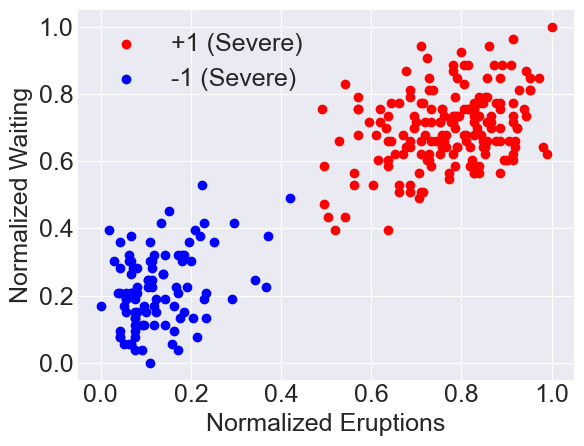

In [17]:
# YOUR CODE HERE
# Load Data & Select Variables, X:feature matrix
data = pd.read_csv("Data/old_faithful.csv")
X = data[["eruptions", "waiting"]].to_numpy()
# Assign Output Classes, y: labels/target
y = data["severe"].to_numpy()
# Preprocessing data using min-max normalization, X_norm: normalized X
# Formula: (X - col_min) /(col_max - col_min)
col_min, col_max = X.min(axis=0), X.max(axis=0)
X_norm = (X - col_min) / (col_max - col_min)
# Matplotlib
plt.scatter(X_norm[y == 1, 0], X_norm[y == 1, 1], color="red", label="+1 (Severe)") # True, mask->x & y-axis 
plt.scatter(X_norm[y == -1, 0], X_norm[y == -1, 1], color="blue", label="-1 (Severe)") # False, mask -> x & y-axis
plt.xlabel("Normalized Eruptions")
plt.ylabel("Normalized Waiting")
plt.legend()
plt.show()

### 1c. Train ADALINE on normalized Old Faithful data using default hyperparameters (i.e. learning rate, epochs)

Print out the final loss and accuracy, then use the provided function to plot your training results inline in the below cell.

By the final epoch, training loss should reach ~11.36 and accuracy ~100%.

In [18]:
# YOUR CODE HERE
# Train ADALINE on normalized data
loss_list, accuracy_list = net.fit(X_norm, y) # y is true labels
print("Final Loss:", loss_list[-1]) # list[-1]: last element in epoch 
print("Final Accuracy:", accuracy_list[-1])

Final Loss: 11.356146465887932
Final Accuracy: 1.0


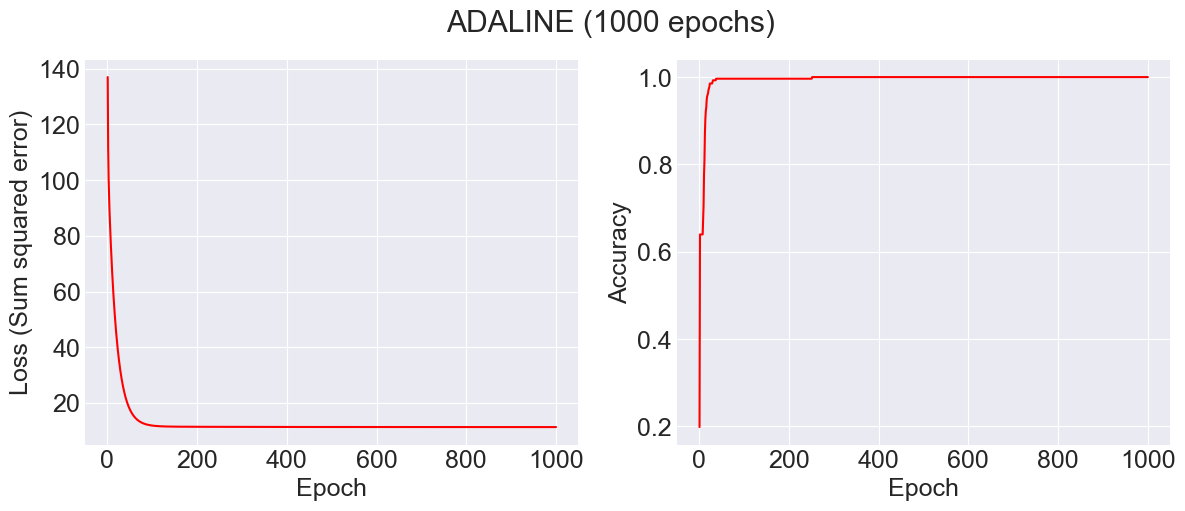

In [19]:
def plot_adaline_train(net, loss_list, acc_list, plotMarkers=False, title='ADALINE'):
    '''Helper plotting function provided for you.'''
    n_epochs = len(loss_list)

    x = np.arange(1, n_epochs+1)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    fig.suptitle(f'{title} ({n_epochs} epochs)')

    curveStr = '-r'
    if plotMarkers:
        curveStr += 'o'

    ax1.plot(x, loss_list, curveStr)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (Sum squared error)')
    ax2.plot(x, acc_list, curveStr)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')

    plt.show()

# YOUR CODE HERE
plot_adaline_train(net, loss_list, accuracy_list, plotMarkers=False, title="ADALINE")


#### Questions

**Question 1.** Based on your loss and accuracy curves, does it look like your network learned to classify the old faithful data? Why or why not?

**Answer 1:**

Yes, the network learned to classify the old faithful data as seen with the Accuracy in the epoch rising to **1.0** and becoming stagnent for further iterations, while the SSE loss decreases every iteration until becoming stagnent at around **11.36** proving that the weights in the network convergeed to a solution that ensured in classifying all training samples. SSE not reaching zero it so be guessed since ADALINE only minimizes squared error on continous outpouts and not 0-1 classification error.

## Task 2: Feature scaling and hyperparameters


### 2a. Feature scaling

Copy your code from Task 1 to import the Old Faithful data, but this time don't normalize before training.

In [22]:
# YOUR CODE HERE
data = pd.read_csv("Data/old_faithful.csv")
X = data[["eruptions", "waiting"]].to_numpy()
y = data["severe"].to_numpy()
loss_list, accuracy_list = net.fit(X, y)
print("Final Loss:", loss_list[-1])
print("accuracy_list:", accuracy_list[-1])

Final Loss: nan
accuracy_list: 0.3602941176470588


#### Questions

**Question 2.** What happens to the loss when we don't normalize the features before training? Why?

**Answer 2:**

When features are not normalized before training then the loss becomes NaN since it diverges. Thus, the training process produces overflows because the large scale of the inputs causes very large weight updates during gradient descent. As a result, the output becomes excessively large that leads to large squared errors and numerical instability in the model. Feature scaling is vital for stable training in ADALINE.

### 2b. Test how individually standardizing your features affects the rate at which loss decreases over epochs

1. Write code in the cell below to train the network on standardized features. Recall that standardizing a variable means applying the transformation $\frac{x - \mu}{\sigma}$. The mean and standard deviation should be computed over the entire dataset and separately per feature.
2. Plot the loss and accuracy.

**The cell should generate an inline pair of plots when executed**.

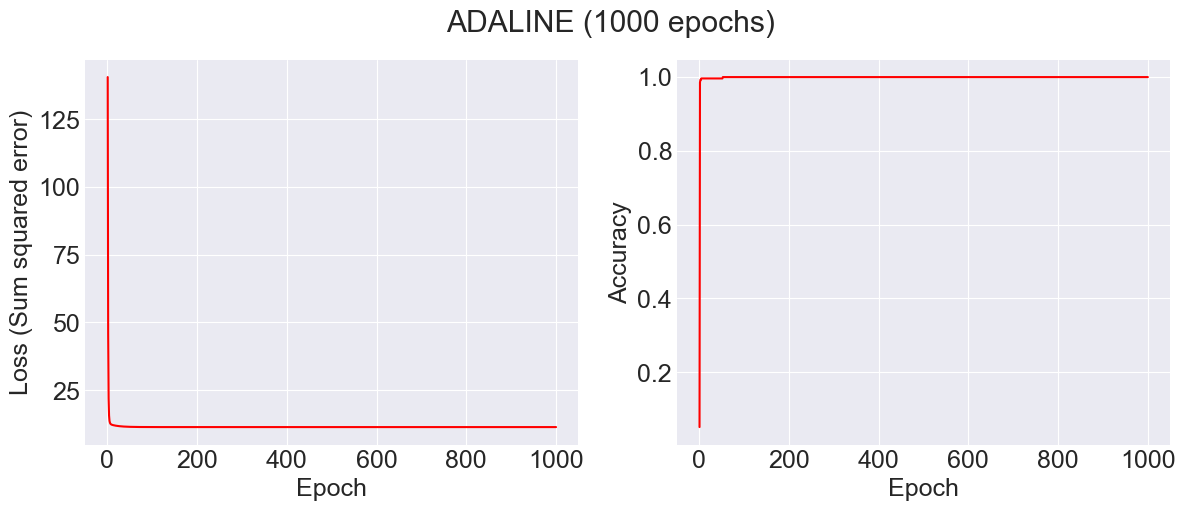

Final Loss: 11.352774233866423
Final Accuracy: 1.0


In [23]:
# YOUR CODE HERE

# 1. train network on standardized features
X_standardized = (X - X.mean(axis=0)) / X.std(axis=0) # 0 - column
# train new network on standarized data
net = Adaline()
loss_list, accuracy_list = net.fit(X_standardized, y)
# 2. Plot loss and accruacy
plot_adaline_train(net, loss_list, accuracy_list, plotMarkers=False, title="ADALINE")
print("Final Loss:", loss_list[-1])
print("Final Accuracy:", accuracy_list[-1])

#### Questions

**Question 3.** Explain the similarities/differences in loss and accuracy curves between these plots and those that you made in Task 1.

**Answer 3:**

The similarities in loss and accuracy curves between plots in task 2b and the plots in task 1 would be the loss decreases over epochs and accuracy still rises to 1.0, which showcases that the network successfully learned to classify the data in both min-max normalized features and standardized features. A difference though would be while training the standardized features the network decreases loss at a faster rate in the early epochs and model converges a little bit faster. The reason for this is due to standardization, each feature is centered around the zero and is scaled to unit variance, which results in the conditioning improving optimization and each gradient update is more balanced. On the contrary, min-max normalized scales features to [0, 1] but does not center the features making convergence slower for the model. However, even with the differences both methods provide very similar final results.

### 2c. Influence of learning rate

This subtask focuses on the influence of learning rate (a model **hyperparameter**) on the quality of neural network training.

#### Questions

**Question 4:** Make small changes to the learning rate hyperparameter below. How does it affect the loss? **Make 1+ plots that clearly support what you notice.**

**Answer 4:**

The changes in the learning rate hyperparameter significantly affects how quickly and stably the loss decreases. A very small learning rate results in slow convergence because the weight updates are tiny. A moderate learning rate produces faster convergence and smooth loss reduction. While a large learning rate can cause the loss to oscillate or diverge because the updates overshoot the minimum of the loss function. Thus, ensuring a proper learning rate is chosen is vital for effective training.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


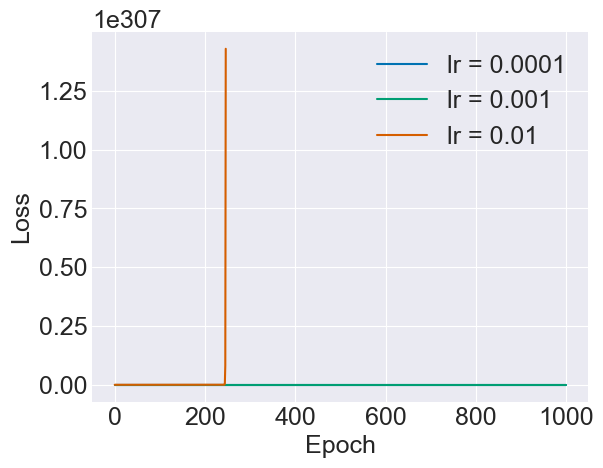

In [24]:
# YOUR CODE HERE

# Small Learning Rate
net_small = Adaline()
loss_small, accuracy_small = net_small.fit(X_standardized, y, lr=0.0001)
# Medium Learning Rate
net_medium = Adaline()
loss_medium, accuracy_medium = net_medium.fit(X_standardized, y, lr = 0.001)
# Large Learning Rate
net_large = Adaline()
loss_large, accuracy_large = net_large.fit(X_standardized, y, lr=0.01)
# Plots for all loss curves
plt.plot(loss_small, label="lr = 0.0001")
plt.plot(loss_medium, label="lr = 0.001")
plt.plot(loss_large, label="lr = 0.01")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Question 5:** What happens to the loss if the learning rate is increased by several orders of magnitude? Why? **Make 1+ plots that clearly support what you notice.**

**Answer 5:**

When the learning rate is increased by several orders of magnitude then the loss diverges instead of decreasing. The update to the weights become excessively large which results in the optimization process to overshoot the minimum of the loss function repeatedly. Thus, leading to unstable training, oscillations, numerical overflow that produces NaN values halting the network from converging. 

/Users/vivianhu/Downloads/Proj2/adaline.py:144: RuntimeWarning: overflow encountered in multiply
  grad_wts = -np.sum(errors[:, np.newaxis] * features, axis = 0)


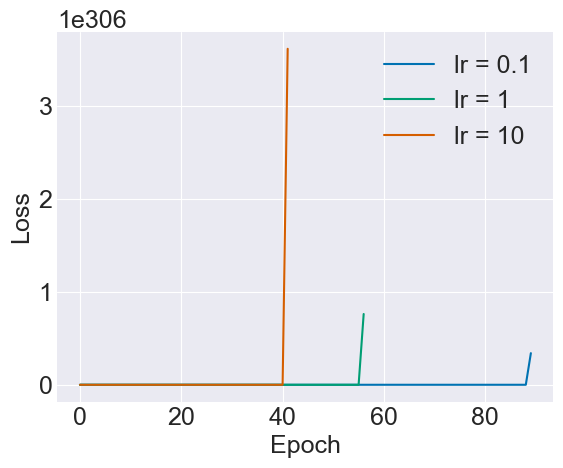

In [25]:
# YOUR CODE HERE

# Small Learning Rate
net1 = Adaline()
loss1, accuracy1 = net1.fit(X_standardized, y, lr=0.1)
# Medium Learning Rate
net2 = Adaline()
loss2, accuracy2 = net2.fit(X_standardized, y, lr = 1)
# Large Learning Rate
net3 = Adaline()
loss3, accuracy3 = net3.fit(X_standardized, y, lr=10)
# Plot
plt.plot(loss1, label="lr = 0.1")
plt.plot(loss2, label="lr = 1")
plt.plot(loss3, label="lr = 10")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 2d. Visualize class boundaries

For this subtask, you will plot the boundary between points (`eruptions`, `waiting` feature pairs) that get classified as severe (+1) or not (-1). To get there, fill in the blanks and answer the questions below.

weights: [0.704 0.229]
bias: 0.2794117647058819


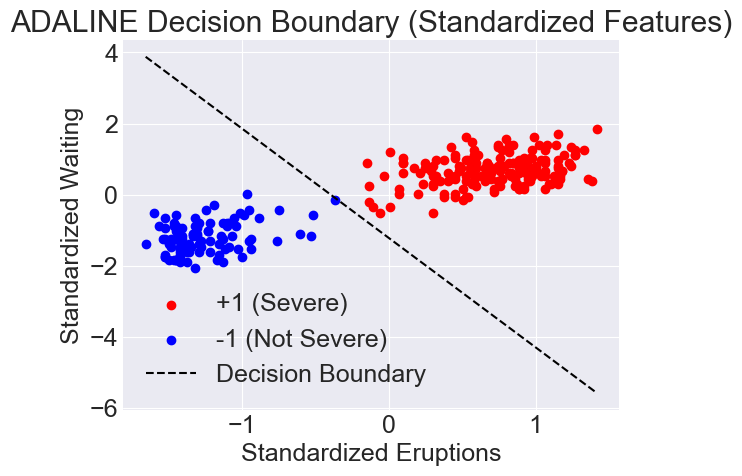

In [26]:
# Print your learned wts and bias here after training net on standardized samples
w = net.get_wts()
b = net.get_bias()
print("weights:", w)
print("bias:", b)
# YOUR CODE HERE
# Weights and Bias 
w0, w1 = w[0], w[1] # weight for features, 0 - eruptions & 1 - waiting
# Decision Boundary: w0*x0 + w1x1 + b = 0 => x1 = -(w0*x0 + b) / w1
x0_min, x0_max = X_standardized[:, 0].min(), X_standardized[:, 0].max()
x0_line = np.linspace(x0_min, x0_max, 200)
x1_line = -(w0 * x0_line + b) / w1
#  Scatterplot of Standardized Data W/ Decision Boundary
plt.scatter(X_standardized[y == 1, 0], X_standardized[y == 1, 1], color = "red", label = "+1 (Severe)")
plt.scatter(X_standardized[y == -1, 0], X_standardized[y == -1, 1], color = "blue", label = "-1 (Not Severe)")
plt.plot(x0_line, x1_line, "k--", label = "Decision Boundary")
plt.xlabel("Standardized Eruptions")
plt.ylabel("Standardized Waiting")
plt.title("ADALINE Decision Boundary (Standardized Features)")
plt.legend()
plt.show()

#### Questions

**Question 6.** What is the meaning of each of the above learned weights with respect to the variables/features in the dataset?

*Hint:* Look at your `net_in` equation, look at the features that you feed into the model, look at the scatterplot you made in 1b, think about what features are present in a single training sample.

**Question 7.** Which feature / weight index corresponds to the "y axis value" in your scatterplot from 1b?

**Answer 6:** 

Each learned weight represents how strongly the corresponding standardized feature influences the model's prediction of whether an eruption is severe or not. A larger magnitude weight indicates that a change in that feature will have a greater influence on the classification. The sign of the weight determines the direction of the influence, a positive weight ensures that larger feature values increase likelihood of predicting the severe class, while a negative weight just means that larger feature values decrease the prediction of the severe class. The standardized features can also be compared to see which feature is more important for classification.

**Answer 7:**

The feature / weight index that corresponds to the "y axis value" in the scatterplot in task 1b would be the **waiting** feature, second column of the input data thus corresponding to the weight index(w1) in the learned weight vector.

#### Transform weights for plotting

The class boundary equation is $0 = w_0 + w_1 \times x_i + w_2 \times y_i$ for sample $i$ in our data ($i$ goes to 272). But to plot it, we need an equation that looks like $y_i = m \times x_i + b$ where $m$ and $b$ are some combinations of our weights.

1. Scale the weights so that the one corresponding to the "y value" is set to 1, then solve for $y$ (*It might be helpful to work this out by hand*). Once you do, adjust the sign/scale of your weights in code so they match up with the equation you wrote out by hand ( of form $y_i = m \times x_i + b$). **Be careful about the order in which you manipulate the bias and weight values when setting up your equation.**
2. Once you're done, have the cell below print your transformed weights/bias.

In [27]:
# YOUR CODE HERE
# Scale weights, 0 = w0+w1 * X + w2 * y => y = m x + c
m = - w0/ w1
c = -b / w1 
# Print transformed weights/bias
print("Slope (m):", m)
print("Intercept (c):", c)

Slope (m): -3.0762714656877366
Intercept (c): -1.2207959082285418


In the cell below, sample 50 equally spaced x values from -1.5 to 1.5 for plotting the class boundary. Given the `x_i` values, generate `y_i` values using the equation $y_i = m \times x_i + b$ (using your transformed weights from above). 

**Executing the code below should produce a graph that clearly shows this class boundary superimposed on your data scatter plot.**

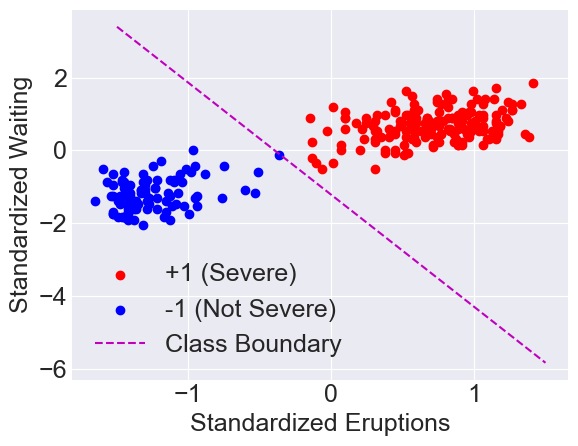

In [28]:
# YOUR CODE HERE
# Compute Values
x_i = np.linspace(-1.5, 1.5 ,50)
y_i = m * x_i + c # c is intercept from transformed equation
# Plot Scatterplot & Transformed Boundary line
plt.scatter(X_standardized[y == 1, 0], X_standardized[y == 1, 1], color = "red", label = "+1 (Severe)")
plt.scatter(X_standardized[y == -1, 0], X_standardized[y == -1, 1], color = "blue", label = "-1 (Not Severe)")
plt.plot(x_i, y_i, "m--",label="Class Boundary")
plt.xlabel("Standardized Eruptions")
plt.ylabel("Standardized Waiting")
plt.legend()
plt.show()

## Task 3: Perceptron: A neural network with a different activation function

In this task, you will apply ADALINE to a larger dataset ([Ionosphere dataset](https://archive.ics.uci.edu/dataset/52/ionosphere)) and compare the performance of ADALINE with another binary classification neural network . A **Perceptron** is a single-layer neural network that works exactly the same as ADALINE, except it uses a different network activation function (`netAct`). The activation function computes the `netAct` as follows:

$$\text{netAct}_i = f(\text{netIn}_i) = 1  \text{ if netIn}_i \geq 0$$
$$\text{netAct}_i = f(\text{netIn}_i) = -1 \text{ if netIn}_i < 0$$

### 3a. Implement and test a Perceptron

1. Create a new class in `adaline.py` that will represent your Perceptron classifier. It should inherit from `Adaline`. Override/write any necessary functions. **Hint:** This should be really quick, short, and simple.
2. In the cell below, train your Perceptron on the same standardized Old Faithful data by making loss and accuracy plots like you have been using in previous tasks (*though you should replace the default title in `plot_adaline_train` with Perceptron*).

If everything is working, you should get very similar results with your Perceptron as above with ADALINE.

In [29]:
from adaline import Perceptron

In [30]:
# YOUR CODE HERE

# Create Perceptron
net = Perceptron()

# Train on Standardized data
loss_list, accuracy_list = net.fit(X_standardized, y)


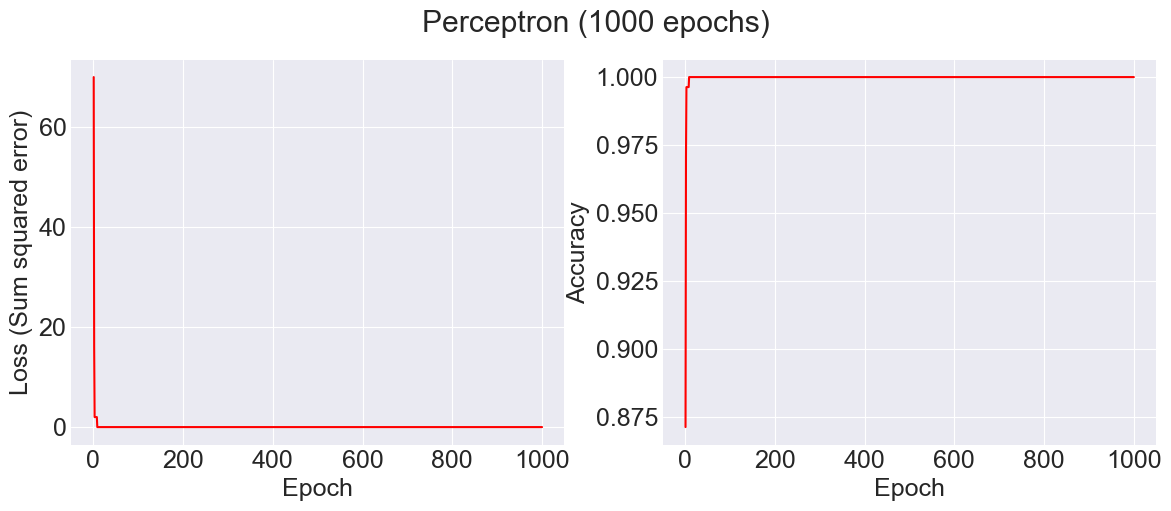

In [31]:
# YOUR CODE HERE
# Plot
plot_adaline_train(net, loss_list, accuracy_list, plotMarkers=False, title="Perceptron")

### 3b. Compare performance between ADALINE and Perceptron on Ionosphere dataset

Your goal is to train, compare, and analyze the performance of your ADALINE and Perceptron networks on the Ionosphere dataset.

The [Ionosphere dataset](https://archive.ics.uci.edu/dataset/52/ionosphere) is radar signal data collected in Goose Bay, Labrador. It is a more complex dataset than old faithful, with 33 features (but still 2 classes). The class values are coded 'g' for good radar signal and 'b' for bad radar signal.

**Please download the CSV file from the CS343 project website (not above UCI link)** — I have slightly modified the dataset for your convenience.

**TODO:**
1. Load in and normalize the Ionosphere dataset by standardization. Note that there are no headers in the CSV file and the class values are specified in the last column — **make sure that they are coded properly** (i.e. $-1$ and $+1$).
2. In the cell below, use the provided `plot_nets_train` helper function to create a 1x2 plot showing training loss and accuracy of the two networks.

Your goal is to play with the hyperparameters until both networks **start** plateauing in accuracy. Your accuracy doesn't literally need to stop increasing — you just want the visual impression of it doing so. Don't train the networks too long so that you miss the early trend in loss and/or accuracy.

In [32]:
def plot_nets_train(loss_lists, acc_lists, net_names, plotMarkers=False):
    '''Creates a 1x2 grid of plots showing loss over epochs (left column) and
    accuracy over epochs (right column) for one or more network (num_nets in total).
    Generalizes `plot_adaline_train` for multiple trained networks.

    For example, in the case of two networks (e.g. adaline and perceptron; num_nets=2),
    there would be two curves in each of the two plots.

    Put differently, the following function call would produce the same pair of plots you've
    been getting up until this point with a single adaline network:
        plot_adaline_train(loss_lists[0], acc_lists[0])

    Parameters:
    -----------
    loss_lists: Python lists of ndarrays. len(loss_lists) = num_nets. len(loss_lists[0]) = n_epochs.
        This would be a list of the loss histories for each of the nets being plotted.
    acc_lists: Python lists of ndarrays. len(acc_lists) = num_nets. len(acc_lists[0]) = n_epochs.
        This would be a list of the accuracy histories for each of the nets being plotted.
    net_names: Python list of str. len(net_names) = num_nets.
        Identifying names of each net (e.g. for legend).
    plotMarkers: boolean.
        Should we draw a plot marker at each epoch on each curve?
    '''
    n_nets = len(net_names)
    n_epochs = len(loss_lists[0])

    colors = ['orange', 'blue', 'red']

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    fig.suptitle(f'{n_nets} networks trained for ({n_epochs} epochs)')

    for loss_list, acc_list, color in zip(loss_lists, acc_lists, colors):
        x = np.arange(1, n_epochs+1)

        curveStr = '-'
        if plotMarkers:
            curveStr += 'o'

        ax1.plot(x, loss_list, curveStr, c=color)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss (Sum squared error)')
        ax2.plot(x, acc_list, curveStr, c=color)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')

    plt.legend(net_names)
    plt.show()

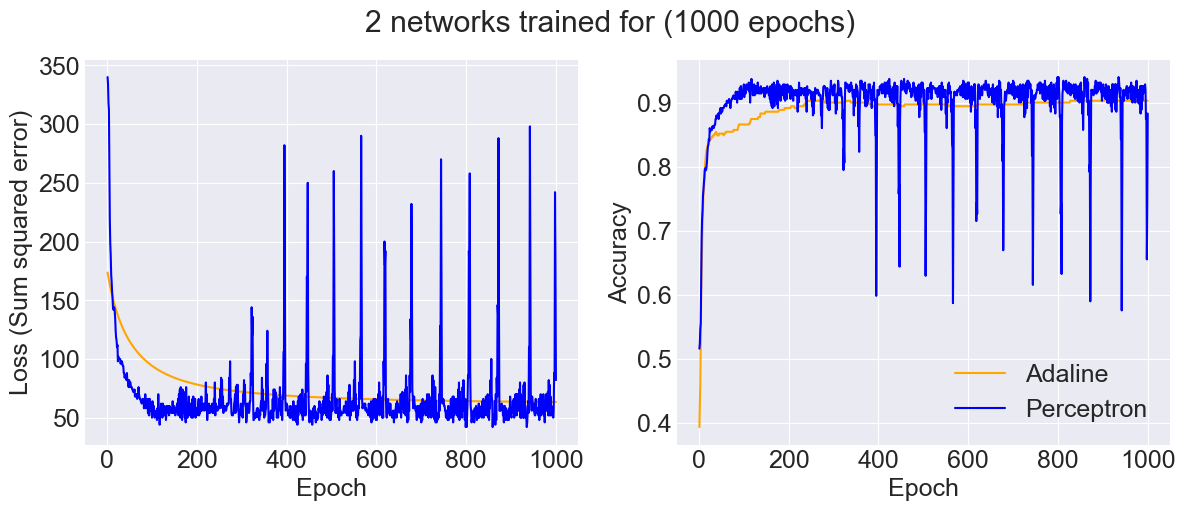

Final Adaline Accuracy: 0.9031339031339032
Final Perceptron Accuracy: 0.8831908831908832


In [33]:
# YOUR CODE HERE

# Load Data
data = pd.read_csv("Data/ionosphere.csv", header=None)
# Split into features & labels
X = data.iloc[:, :33].to_numpy().astype(float)
y_raw = data.iloc[:, -1].to_numpy()
# Encode labels, 'g' -> 1, 'b' -> -1
y = np.where(y_raw == 'g', 1, -1)
# Standardized features
X_std = (X - X.mean(axis=0)) / X.std(axis=0) # 0 - column
# Train Models
net_adaline = Adaline()
net_perceptron = Perceptron()
# Loss & Accuracy for both models
loss_history_adaline, accuracy_history_adaline = net_adaline.fit(X_std, y, n_epochs=1000, lr=1e-5)
loss_history_perceptron, accuracy_history_perceptron = net_perceptron.fit(X_std, y, n_epochs=1000, lr=1e-5)
# Plot
loss_lists = [loss_history_adaline, loss_history_perceptron]
accuracy_lists = [accuracy_history_adaline, accuracy_history_perceptron]
net_names = ["Adaline", "Perceptron"]
plot_nets_train(loss_lists, accuracy_lists, net_names, plotMarkers=False)
print("Final Adaline Accuracy:", accuracy_history_adaline[-1])
print("Final Perceptron Accuracy:", accuracy_history_perceptron[-1])



#### Questions

**Question 8.** What accuracy are you able to achieve on the Ionosphere dataset with each networks at the end of training?

**Answer 8:** 

The accuracy I am able to achieve on the ionosphere dataset with each networks at the end of training is 90% for Adaline and ~91% for Perceptron.

### 3c. Influence of learning rate

Now let's analyze the effect learning rate on the nets. Make plots that illustrate the effect of the following on ADALINE and Perceptron learning.

1. learning rate increased by 1+ order of magnitude in each network.
2. learning rate decreased by 1+ order of magnitude in each network. *You will likely need to increase the number of training epochs too.*

#### Questions

**Question 9:** Interpret the difference in behavior between the two nets.

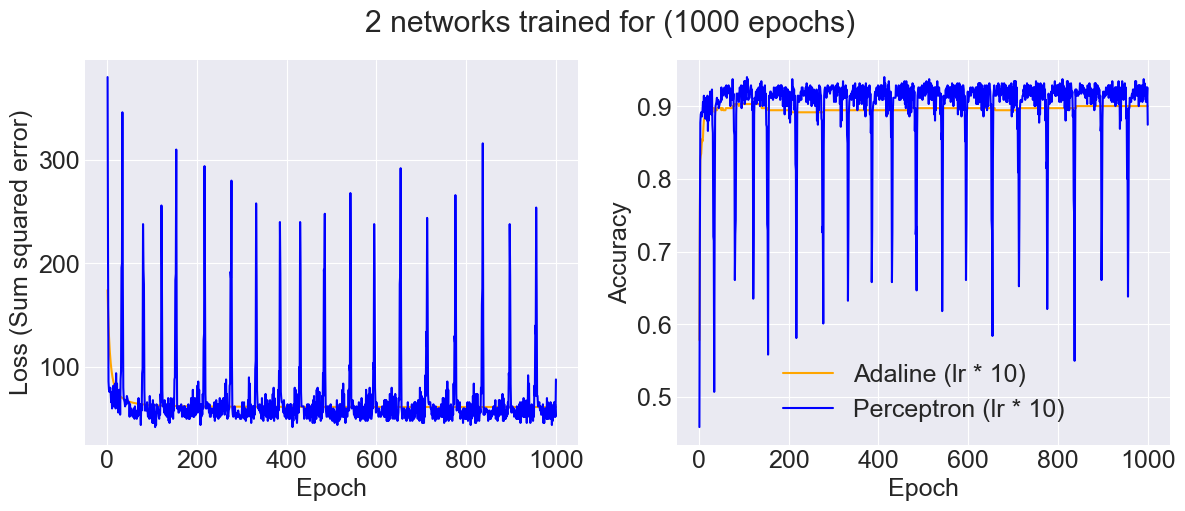

In [34]:
# YOUR CODE HERE
lr_base = 1e-5
n_epochs_base = 1000
lr_high = lr_base * 10
adaline_high = Adaline()
perceptron_high = Perceptron()
loss_adaline_high, accuracy_adaline_high = adaline_high.fit(X_std, y , n_epochs=n_epochs_base, lr=lr_high)
loss_perceptron_high, accuracy_perceptron_high = perceptron_high.fit(X_std, y , n_epochs=n_epochs_base, lr=lr_high)
plot_nets_train(
    [loss_adaline_high, loss_perceptron_high],
    [accuracy_adaline_high, accuracy_perceptron_high],
    ["Adaline (lr * 10)", "Perceptron (lr * 10)"],
    plotMarkers=False
)

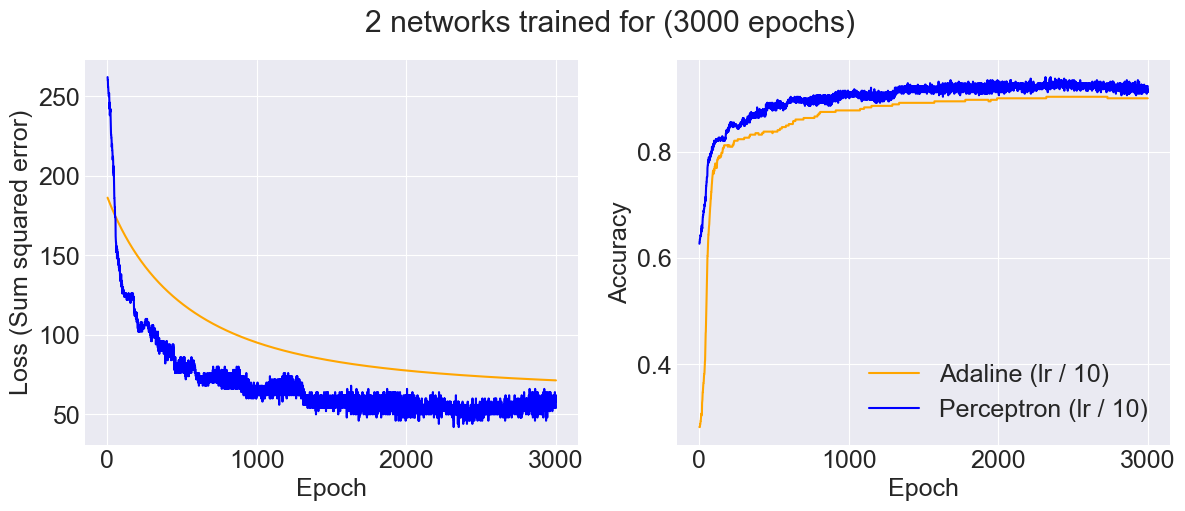

In [35]:
# YOUR CODE HERE    
n_epochs_low = 1000 * 3
lr_low = lr_base / 10
adaline_low = Adaline()
perceptron_low = Perceptron()
loss_adaline_low, accuracy_adaline_low = adaline_low.fit(X_std, y , n_epochs=n_epochs_low, lr=lr_low)
loss_perceptron_low, accuracy_perceptron_low = perceptron_low.fit(X_std, y , n_epochs=n_epochs_low, lr=lr_low)
plot_nets_train(
    [loss_adaline_low, loss_perceptron_low],
    [accuracy_adaline_low, accuracy_perceptron_low],
    ["Adaline (lr / 10)", "Perceptron (lr / 10)"],
    plotMarkers=False
)

**Answer 9:**

When the learning rate is increased by an order of magnitude, both networks showcase unstable training behavior, ADALINE loss showcases large oscillations and spikes instead of steadily decreasing over time, while Perceptron accuracy fluctuates significantly, which means that updates are overshooting the optimal solution. However, when the learning rate is decreased there is slower but smoother learning where the loss steadily decreases and accuracy improves before becoming stagnant after many epochs. This showcases the relationship between learning rates, accuracy and loss where high learning rates speed up learning but risk instability, while low learning rates promote stagnant convergence at the cost of training time. ADALINE is sensitive to large learning rates due to optimizing a continuos squared-error loss via gradient descent, where Perceptron step-based updates produces more jagged accuracy but remains robust

### 3d. Plotting classifications

Make two scatter plots (one per network) showing the feature at index 4 on x-axis and the feature at index 19 on the y-axis. Samples should be color coded one of two colors: whether the class was correctly or incorrectly predicted.


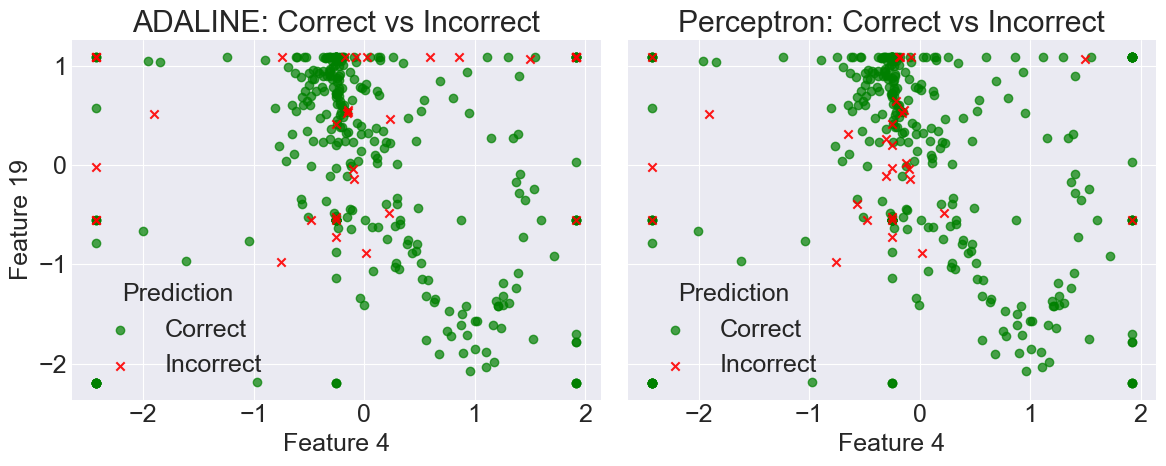

In [36]:
# YOUR CODE HERE

# Predictions
y_predictions_adaline = net_adaline.predict(X_std)
y_predictions_perceptron = net_perceptron.predict(X_std)
# Masks, incorrect/correct
correct_adaline = (y_predictions_adaline == y)
correct_perceptron = (y_predictions_perceptron == y)
# Plotting features
x_idx, y_idx = 4, 19
x_values = X_std[:, x_idx]
y_values = X_std[:, y_idx]
# Scatterplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
axes[0].scatter(x_values[correct_adaline], y_values[correct_adaline], color="green", marker = "o", label="Correct", alpha=0.7) # ADALINE
axes[0].scatter(x_values[~correct_adaline], y_values[~correct_adaline], color="red", marker="x",label="Incorrect", alpha=0.9)
axes[0].set_title("ADALINE: Correct vs Incorrect")
axes[0].set_xlabel(f"Feature {x_idx}")
axes[0].set_ylabel(f"Feature {y_idx}")
axes[0].legend(title="Prediction")

axes[1].scatter(x_values[correct_perceptron], y_values[correct_perceptron], color="green", marker="o",label="Correct", alpha=0.7) # PERCEPTRON
axes[1].scatter(x_values[~correct_perceptron], y_values[~correct_perceptron], color="red", marker="x",label="Incorrect", alpha=0.9)
axes[1].set_title("Perceptron: Correct vs Incorrect")
axes[1].set_xlabel(f"Feature {x_idx}")
axes[1].legend(title="Prediction")

plt.tight_layout()
plt.show()


#### Questions

**Question 10:** In your scatter plots showing correct and incorrect sample classifications, how is it possible that misclassifications are so dispersed and do not appear to either side of a simple boundary?

**Answer 10:** 

Classification feels dispersed since both models are trained on all 33 features of the ionosphere dataset, but the scatter plot only focuses on two of those features(features 4 and 19). The true decision boundary exists on a high-dimensional space and depends on the weighted combination of all features, not just these two. Thus, when the data is displayed on a 2D plane the points are overlapping and appear randomly distributed illustrating errors to look scattered instead of concentrated on a single line, so the plot doesn't reflect actual geometry of the classifier but instead a very small view.